# Тензорный считыватель
```pip install numpy```

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*:
```[a][b][c][d][e] -> [a][b][d][c][e]```

В классе Tensor это условие учтено, в остальном - нужно следить **самостоятельно**!

In [1]:
import numpy as np
import itertools as it
from math import *
from enum import Enum
import re

def geolin_clear(s: str) -> str:
    return s.replace('−', '-').replace('\u200b', '')

class TStatus(Enum):
    EVEN = 0
    VERTICAL = 1
    HORIZONTAL = 2

class Tensor:
    t: list
    dim: int
    covector: int
    vector: int
    deep: int
    status: TStatus
    
    def __init__(self, s, dim: int, covector: int, vector: int, status: TStatus = None, a_type=int):
        # Check dimensions and indexes
        if covector + vector <= 0:
            raise ValueError('ERR: 0 indexes for vectors or covectors')
            
        # Set dimensions
        self.dim = dim
        self.covector, self.vector = covector, vector
        self.deep = covector + vector
        
        # Check status
        if self.deep % 2:
            if status is not None and status != TStatus.EVEN:
                self.status = status
            else:
                self.status = (TStatus.VERTICAL if self.vector == 0 else TStatus.HORIZONTAL)
        else:
            self.status = TStatus.EVEN
        
        if isinstance(s, str):
            # Clear string data
            s = s.replace('−', '-').replace('\u200b', '').split()
            # Empty t
            self.t = np.zeros([self.dim] * self.deep, a_type)
            
            if self.status is TStatus.HORIZONTAL:
                divisors = [ind // 2 + (self.deep // 2 if ind % 2 else 0) for ind in range(self.deep - 1)] + [self.deep - 1]
            else:
                divisors = [ind // 2 + (self.deep // 2 + self.deep % 2 if ind % 2 else 0) for ind in range(self.deep)]
                
            for m in range(len(s)):
                index = [m // (self.dim ** div) % self.dim for div in divisors]
                self.t[*index] = s[m]
                # print(m + 1, '=', ', '.join(str(x + 1) for x in index), '=', s[m])
        elif isinstance(s, (np.ndarray, np.generic)):
            self.t = s
        else:
            self.t = np.zeros([self.dim] * self.deep, a_type)

    def _iterate_show(self):
        """Переборный интератор для show
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        axes = list(range(self.deep - 1, -1, -1))
        if self.status is TStatus.HORIZONTAL:
            order = [ax for ax in axes if ax % 2 == 0 and ax != axes[0]] + [axes[0]] + [ax for ax in axes if ax % 2 != 0]
        else:
            order = [ax for ax in axes if ax % 2 == 0] + [ax for ax in axes if ax % 2 != 0]
        # print(axes, order)
        for indices in it.product(range(self.dim), repeat=self.deep):
            original_indices = [0] * self.deep
            for original_axis in range(self.deep):
                pos = order.index(original_axis)
                original_indices[original_axis] = indices[pos]
            yield tuple(original_indices)

    
    def show(self, sym_element=' ', sym_line='\n', sym_superline='\n\n', sym_superraw=' | ') -> str:
        """Превращает тензор в текст для вывода:
            sym_element: между двумя элементами, sym_line: перенос каждую строку,
            sym_superline: перенос каждую суперстроку, sym_superraw: перенос каждый суперстолбец.
        
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        s = ''
        pre_line, pre_superline, pre_superraw = 0, 0, 0
        for indices in self._iterate_show():
            if len(indices) == 1:
                if (pre_line != indices[0]) and (self.status is TStatus.VERTICAL):
                    s += sym_line
                elif indices[0] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 2:
                if (pre_line != indices[0]):
                    s += sym_line
                elif indices[0] != 0 or indices[1] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 3:
                if self.status is TStatus.HORIZONTAL:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superraw != indices[2]):
                        s += sym_superraw
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superraw = indices[0], indices[2]
                else:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superline != indices[2]):
                        s += sym_superline
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superline = indices[0], indices[2]
            else:
                if (pre_line != indices[0]):
                    s += sym_line
                elif (pre_superline != indices[2]):
                        s += sym_superline
                elif (pre_superraw != indices[3]):
                    s += sym_superraw
                elif not all(i == 0 for i in indices):
                    s += sym_element
                pre_line, pre_superline, pre_superraw = indices[0], indices[2], indices[3]
            # print(indices)
            s += str(self.t[indices])
        return s
    
    @property
    def format(self):
        return '[' + self.show(', ', '; ', ', ', ', ') +']'
    
    def __getitem__(self, prop):
        return self.t[prop]
    
    def __setitem__(self, key, value):
        self.t[key] = value
    
    def __str__(self):
        return f'Tensor ({self.vector}, {self.covector}), dim = {self.dim}, status = {self.status}\n' + self.show() + '\n' + self.format
    
    def __repr__(self):
        return f'Tensor ({self.vector}, {self.covector})'
    
    def __mul__(self, other):
        return Tensor(other * self.t, self.dim, self.covector, self.vector, self.status)
    
    def __add__(self, other):
        return Tensor(self.t + other.t, self.dim, self.covector, self.vector, self.status)
    
    def __sub__(self, other):
        return Tensor(self.t - other.t, self.dim, self.covector, self.vector, self.status)
    
    @staticmethod
    def fuck_geolin(indices, COB):
        indices = list(indices)
        if len(indices) <= 3:
            return indices
        if len(COB)==0:
            return indices
        start = 2  # Начало подсписка для обработки
        if len(indices) % 2:
            # Нечётная длина: обрабатываем элементы со 2 до предпоследнего
            sub_len = len(indices) - 3  # Длина подсписка indices[2:-1]
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed + [indices[-1]]
        else:
            # Чётная длина: обрабатываем все элементы с индекса 2
            sub_len = len(indices) - start
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed
    
    def __matmul__(A, B):
        dim = A.dim
        out = Tensor(0, dim, A.covector + B.covector, A.vector + B.vector, a_type=A.t.dtype)
        for COindicesA in it.product(range(dim), repeat=A.covector):
            for COindicesB in it.product(range(dim), repeat=B.covector):
                for indicesA in it.product(range(dim), repeat=A.vector):
                    for indicesB in it.product(range(dim), repeat=B.vector):
                        indices = Tensor.fuck_geolin(COindicesA + COindicesB + indicesA + indicesB, COindicesB)
                        out[*indices] = A[*(COindicesA+indicesA)] * B[*(COindicesB+indicesB)]     
        return out
        
tens = [
    Tensor('1 2', 2, 1, 0),
    Tensor('1 2', 2, 0, 1),
    Tensor('1 2 3 4', 2, 1, 1),
    Tensor('1 2 3 4 5 6 7 8', 2, 3, 0),
    Tensor('1 2 3 4 5 6 7 8', 2, 0, 3),
    Tensor('1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16', 2, 2, 2),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 5, 0),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 3, 2)
]
# [print('========== ', ten.status, '\n', ten, sep='') for ten in tens[:]]
    

In [2]:
def geolin_matrix(s: str, n: int):
    s = s.replace('−', '-').replace('\u200b', '').split()
    d = np.zeros((n, len(s) // n))
    for i in range(len(s)):
        d[i % n][i // n] = s[i]
    return np.matrix(d)

def geolin_vector(s: str):
    s = s.replace('−', '-').replace('\u200b', '').split()
    return np.array([int(x) for x in s])

def geo(m: np.matrix):
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m.item(0, i), 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m.item(j, i), 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

# Задачи

Задача 1

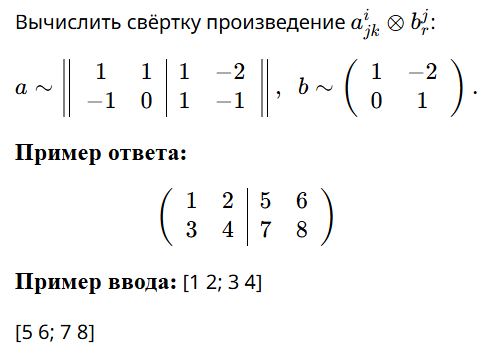

In [5]:
a = "1 −1 ​ 1 0 ​ 1 1 ​ −2 −1"
b = "1 0 ​ −2 1"
A = Tensor(a, 2, 1, 2)
B = Tensor(b, 2, 1, 1)
C = Tensor(0, 2, 1, 2)
for (i, j, k, r) in it.product(range(2), repeat=4):
    C[i][k][r] += A[i][j][k] * B[j][r]
print(C)

Tensor (2, 1), dim = 2, status = TStatus.HORIZONTAL
1 1 | -1 -4
-1 1 | 2 -3
[1, 1, -1, -4; -1, 1, 2, -3]


Семён 1

In [6]:
a = "1 1 1 2​ 1 −1 ​−2 3"
b = "1 -1 1 0"
A = Tensor(a, 2, 1, 2)
B = Tensor(b, 2, 1, 1)
C = Tensor(0, 2, 1, 2)
for (i, j, k, r) in it.product(range(2), repeat=4):
    C[i][k][r] += A[i][j][k] * B[j][r]
print(C)

Tensor (2, 1), dim = 2, status = TStatus.HORIZONTAL
0 3 | 1 1
-1 -4 | 1 -1
[0, 3, 1, 1; -1, -4, 1, -1]


Задача 2

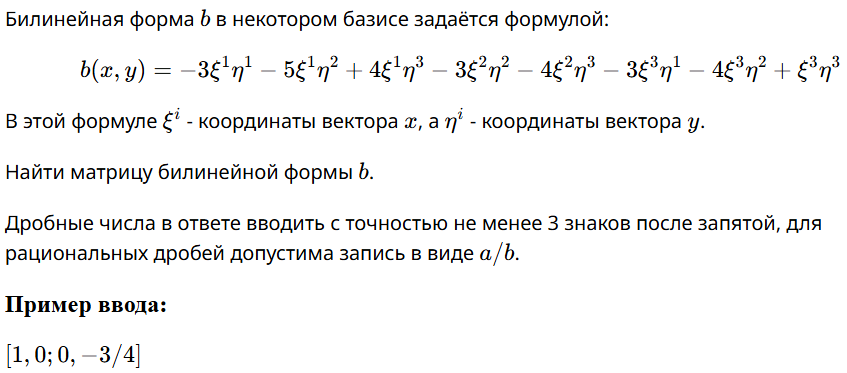

Нужно выделить члены типа $-3ξ^1η^1$, где $a=-3$ - свободный член, $i=1$ - индекс $\xi^i$, $j=1$ - индекс $\eta^j$. Записать в матрицу в ячейку $A^i_j = a$.

Задача 3

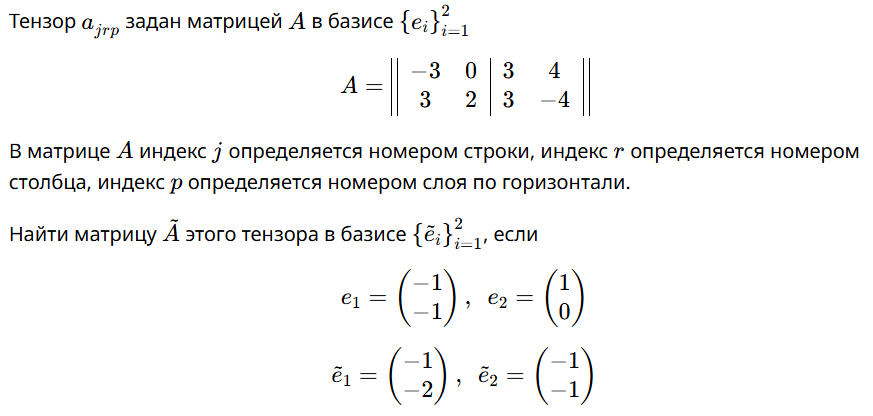

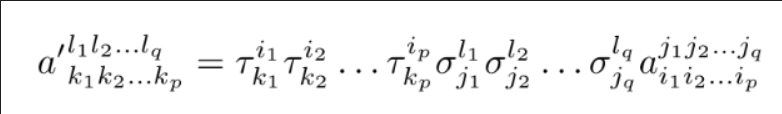

Для моего случая немая сумма будет такая
$\tilde{a}^{}_{jrp} = \tau^{i_1}_{j} * \tau^{i_2}_{r} * \tau^{i_3}_{p} * a^{}_{i_1 i_2 i_3}$

In [ ]:
data = "−3 3 ​ 0 2 ​ 3 3 ​ 4 −4 ​ ​​"
a = Tensor(data, 2, 0, 3)
print(a)

e1, e2 = [-1, -1], [1, 0]
old_basis = np.matrix([[e1[0], e2[0]], [e1[1], e2[1]]], float)
e1, e2 = [-1, -2], [-1, -1]
new_basis = np.matrix([[e1[0], e2[0]], [e1[1], e2[1]]], float)
# print(old_basis, new_basis, sep='\n')

S = np.linalg.inv(new_basis).dot(old_basis)
T = np.around(np.linalg.inv(S), 12)
T, S = np.asarray(T), np.asarray(S)
print(T, S, sep='\n')

print('Решение')
tilde_a = np.zeros((2, 2, 2))
for (j, r, p) in it.product(range(2), repeat=3):
    print(f'a{j}{r}{p} = ', end='')
    total = 0
    for (i1, i2, i3) in it.product(range(2), repeat=3):
        value = T[i1, j] * T[i2, r] * T[i3, p] * a[i1, i2, i3]
        if value:
            print('+', value, end=' ')
        total += value
    print('=', total)
    tilde_a[j, r, p] = total

tilde_a = np.round(tilde_a, 10).astype(int)
res_tensor = Tensor(tilde_a, 2, 0, 3)
print(res_tensor)

Tensor (3, 0), dim = 2, status = TStatus.HORIZONTAL
-3 0 | 3 4
3 2 | 3 -4
[-3, 0, 3, 4; 3, 2, 3, -4]
[[2. 1.]
 [1. 0.]]
[[ 0.  1.]
 [ 1. -2.]]
Решение
a000 = + -24.0 + 12.0 + 8.0 + 12.0 + 6.0 + 4.0 + -4.0 = 14.0
a001 = + -12.0 + 6.0 + 2.0 = -4.0
a010 = + -12.0 + 6.0 + 6.0 + 3.0 = 3.0
a011 = + -6.0 + 3.0 = -3.0
a100 = + -12.0 + 6.0 + 4.0 = -2.0
a101 = + -6.0 = -6.0
a110 = + -6.0 + 3.0 = -3.0
a111 = + -3.0 = -3.0
Tensor (3, 0), dim = 2, status = TStatus.HORIZONTAL
14 3 | -4 -3
-2 -3 | -6 -3
[14, 3, -4, -3; -2, -3, -6, -3]


Семён 3

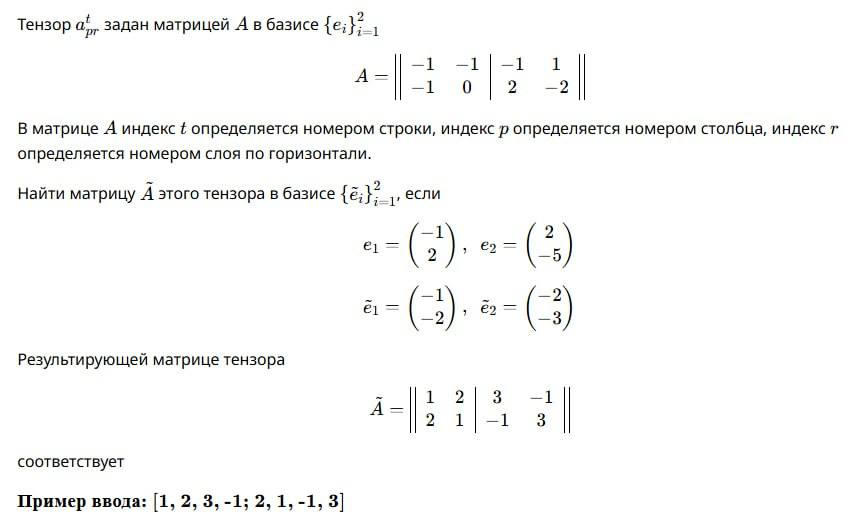

In [18]:
data = "-1 -1 -1 0 -1 2 1 -2"
a = Tensor(data, 2, 1, 2)
print(a)

e1, e2 = [-1, 2], [2, -5]
old_basis = np.matrix([[e1[0], e2[0]], [e1[1], e2[1]]], float)
e1, e2 = [-1, -2], [-2, -3]
new_basis = np.matrix([[e1[0], e2[0]], [e1[1], e2[1]]], float)
# print(old_basis, new_basis, sep='\n')

S = np.linalg.inv(new_basis).dot(old_basis)
T = np.around(np.linalg.inv(S), 12)
T, S = np.asarray(T), np.asarray(S)
print('Матрицы перехода')
print(T, S, sep='\n')

print('Решение')
tilde_a = np.zeros((2, 2, 2))
for (t, p, r) in it.product(range(2), repeat=3):
    print(f'a{t}{p}{r} = ', end='')
    total = 0
    for (i1, i2, j1) in it.product(range(2), repeat=3):
        value = T[i1, p] * T[i2, r] * S[t, j1] * a[j1, i1, i2]
        if value:
            print('+', value, end=' ')
        total += value
    print('=', total)
    tilde_a[t, p, r] = total

tilde_a = np.round(tilde_a, 10).astype(int)
res_tensor = Tensor(tilde_a, 2, 1, 2)
print(res_tensor)

Tensor (2, 1), dim = 2, status = TStatus.HORIZONTAL
-1 -1 | -1 1
-1 0 | 2 -2
[-1, -1, -1, 1; -1, 0, 2, -2]
Матрицы перехода
[[ 9. 16.]
 [ 4.  7.]]
[[-7. 16.]
 [ 4. -9.]]
Решение
a000 = + 567.0 + -1296.0 + 252.0 + 1152.0 + 252.0 + -112.0 + -512.0 = 303.0
a001 = + 1008.0 + -2304.0 + 441.0 + 2016.0 + 448.0 + -196.0 + -896.0 = 517.0
a010 = + 1008.0 + -2304.0 + 448.0 + 2048.0 + 441.0 + -196.0 + -896.0 = 549.0
a011 = + 1792.0 + -4096.0 + 784.0 + 3584.0 + 784.0 + -343.0 + -1568.0 = 937.0
a100 = + -324.0 + 729.0 + -144.0 + -648.0 + -144.0 + 64.0 + 288.0 = -179.0
a101 = + -576.0 + 1296.0 + -252.0 + -1134.0 + -256.0 + 112.0 + 504.0 = -306.0
a110 = + -576.0 + 1296.0 + -256.0 + -1152.0 + -252.0 + 112.0 + 504.0 = -324.0
a111 = + -1024.0 + 2304.0 + -448.0 + -2016.0 + -448.0 + 196.0 + 882.0 = -554.0
Tensor (2, 1), dim = 2, status = TStatus.HORIZONTAL
303 549 | 517 937
-179 -324 | -306 -554
[303, 549, 517, 937; -179, -324, -306, -554]


Задача 4

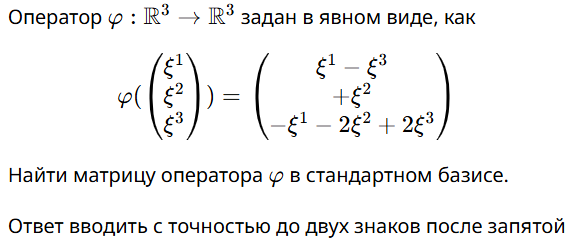

ОЧЕВ

Задача 5

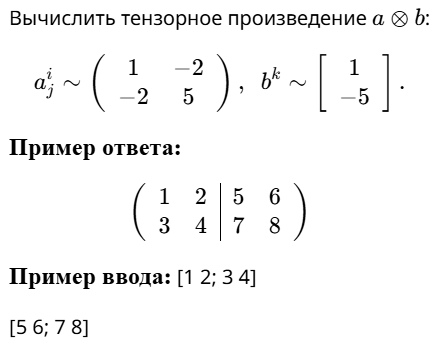

In [15]:
a = "1 -2 -2 5"
b = "1 -5"
A = Tensor(a, 2, 1, 1)
B = Tensor(b, 2, 1, 0)
C = Tensor(0, 2, 2, 1)
print(A, B, sep='\n')
for (i, k, j) in it.product(range(2), repeat=3):
    C[i][k][j] = A[i][j] * B[k]
print(C)

Tensor (1, 1), dim = 2, status = TStatus.EVEN
1 -2
-2 5
[1, -2; -2, 5]
Tensor (0, 1), dim = 2, status = TStatus.VERTICAL
1
-5
[1; -5]
Tensor (1, 2), dim = 2, status = TStatus.HORIZONTAL
1 -5 | -2 10
-2 10 | 5 -25
[1, -5, -2, 10; -2, 10, 5, -25]


Семён 5

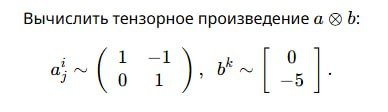

In [16]:
a = "1 0 -1 1"
b = "0 -5"
A = Tensor(a, 2, 1, 1)
B = Tensor(b, 2, 1, 0)
C = Tensor(0, 2, 2, 1)
print(A, B, sep='\n')
for (i, k, j) in it.product(range(2), repeat=3):
    C[i][k][j] = A[i][j] * B[k]
print(C)

Tensor (1, 1), dim = 2, status = TStatus.EVEN
1 -1
0 1
[1, -1; 0, 1]
Tensor (0, 1), dim = 2, status = TStatus.VERTICAL
0
-5
[0; -5]
Tensor (1, 2), dim = 2, status = TStatus.HORIZONTAL
0 -5 | 0 5
0 0 | 0 -5
[0, -5, 0, 5; 0, 0, 0, -5]


Задача 6

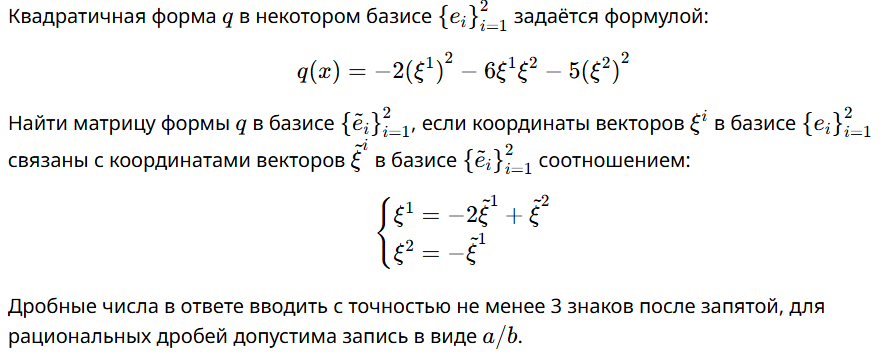

Задача 7

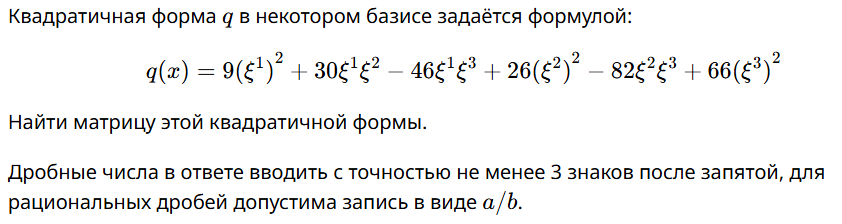

Задача 8

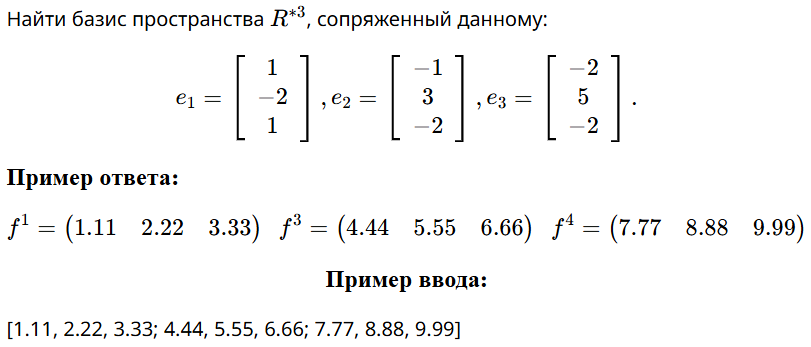

Обратная матрица по строкам